# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [1]:
import random

class Card:
    def __init__(self, suit, rank):
        self.suit, self.rank = suit, rank
    def __repr__(self):
        return f"{self.rank} of {self.suit}"

class Deck:
    def __init__(self, n=6):
        suits = ['H','D','C','S']
        ranks = ['2','3','4','5','6','7','8','9','10','J','Q','K','A']
        self.cards = [Card(s,r) for _ in range(n) for s in suits for r in ranks]
        self.cards.insert(random.randint(0,len(self.cards)), "PLASTIC")
        random.shuffle(self.cards)

    def draw(self):
        c = self.cards.pop(0)
        if c == "PLASTIC":
            print("Reshuffling...")
            self.__init__()
            return self.draw()
        return c

# test
deck = Deck()
print(deck.draw())
print(deck.draw())

3 of S
8 of D


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

## DRAWING IS ATTACHED

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [3]:
class Card:
    
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank


class Deck:
    
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []

    def shuffle(self):
        pass

    def draw(self):
        pass


class Hand:
    
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        pass

    def value(self):
        pass


class Player:
    
    def __init__(self, chips):
        self.chips = chips
        self.hand = None

    def hit(self):
        pass

    def stand(self):
        pass


class Dealer:
    
    def __init__(self):
        self.hand = None

    def play(self):
        pass


class Game:
    
    def __init__(self):
        self.players = []
        self.dealer = None
        self.deck = None

    def start_game(self):
        pass

    def deal_cards(self):
        pass

    def check_winner(self):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [4]:
import random

# Card class
class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank
        self.value = min(rank,10) if isinstance(rank,int) else 10 if rank in ['J','Q','K'] else 11

    def __repr__(self):
        return f"{self.rank} of {self.suit}"


# Deck class
class Deck:
    def __init__(self, num_decks=6):
        suits = ['Hearts','Diamonds','Clubs','Spades']
        ranks = [2,3,4,5,6,7,8,9,10,'J','Q','K','A']

        self.cards = [Card(s,r) for _ in range(num_decks) for s in suits for r in ranks]
        random.shuffle(self.cards)

    def draw(self):
        return self.cards.pop()


# Hand class
class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def value(self):
        total = sum(c.value for c in self.cards)
        aces = sum(1 for c in self.cards if c.rank == 'A')

        while total > 21 and aces:
            total -= 10
            aces -= 1
        return total


# Player class (human)
class Player:
    def __init__(self, name):
        self.name = name
        self.hand = Hand()

    def hit(self, deck):
        self.hand.add_card(deck.draw())

    def play(self, deck):
        while True:
            print(self.name,"hand:",self.hand.cards,"value:",self.hand.value())
            move = input("Hit or Stand? (h/s): ")

            if move == 'h':
                self.hit(deck)
                if self.hand.value() > 21:
                    print("Bust!")
                    break
            else:
                break


# Dealer class
class Dealer:
    def __init__(self):
        self.hand = Hand()

    def hit(self, deck):
        self.hand.add_card(deck.draw())

    def play(self, deck):
        while self.hand.value() < 16:   # dealer rule
            self.hit(deck)


# Game class
class Game:
    def __init__(self):
        self.deck = Deck()
        self.player = Player("Player")
        self.dealer = Dealer()

    def deal_cards(self):
        for _ in range(2):
            self.player.hit(self.deck)
            self.dealer.hit(self.deck)

    def play(self):
        self.deal_cards()

        print("Dealer shows:", self.dealer.hand.cards[0])

        self.player.play(self.deck)

        if self.player.hand.value() <= 21:
            self.dealer.play(self.deck)

        print("Dealer hand:", self.dealer.hand.cards,"value:",self.dealer.hand.value())

        player_val = self.player.hand.value()
        dealer_val = self.dealer.hand.value()

        if player_val > 21:
            print("Dealer wins")
        elif dealer_val > 21 or player_val > dealer_val:
            print("Player wins")
        elif dealer_val > player_val:
            print("Dealer wins")
        else:
            print("Push")


# Run game
game = Game()
game.play()

Dealer shows: 7 of Diamonds
Player hand: [5 of Hearts, 2 of Hearts] value: 7
Hit or Stand? (h/s): h
Player hand: [5 of Hearts, 2 of Hearts, 10 of Spades] value: 17
Hit or Stand? (h/s): h
Bust!
Dealer hand: [7 of Diamonds, 2 of Clubs] value: 9
Dealer wins


5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [5]:
# Test the game with several rounds

for i in range(3):
    print("\n--- Round", i+1, "---")
    game = Game()
    game.play()


--- Round 1 ---
Dealer shows: 7 of Diamonds
Player hand: [3 of Clubs, 2 of Spades] value: 5
Hit or Stand? (h/s): h
Player hand: [3 of Clubs, 2 of Spades, 5 of Spades] value: 10
Hit or Stand? (h/s): h
Player hand: [3 of Clubs, 2 of Spades, 5 of Spades, J of Clubs] value: 20
Hit or Stand? (h/s): h
Bust!
Dealer hand: [7 of Diamonds, 3 of Clubs] value: 10
Dealer wins

--- Round 2 ---
Dealer shows: Q of Clubs
Player hand: [8 of Hearts, 7 of Clubs] value: 15
Hit or Stand? (h/s): h
Player hand: [8 of Hearts, 7 of Clubs, 2 of Hearts] value: 17
Hit or Stand? (h/s): h
Player hand: [8 of Hearts, 7 of Clubs, 2 of Hearts, 3 of Hearts] value: 20
Hit or Stand? (h/s): h
Bust!
Dealer hand: [Q of Clubs, 10 of Hearts] value: 20
Dealer wins

--- Round 3 ---
Dealer shows: J of Diamonds
Player hand: [10 of Diamonds, 4 of Clubs] value: 14
Hit or Stand? (h/s): h
Player hand: [10 of Diamonds, 4 of Clubs, A of Clubs] value: 15
Hit or Stand? (h/s): h
Bust!
Dealer hand: [J of Diamonds, 2 of Clubs] value: 12
Deal

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [6]:
class StrategyPlayer(Player):

    def __init__(self, name):
        super().__init__(name)
        self.count = 0

    def update_count(self, card):
        if card.rank in [2,3,4,5,6]:
            self.count += 1
        elif card.rank in [7,8,9]:
            self.count += 0
        else:
            self.count -= 1

    def play(self, deck):

        # update count for cards already in hand
        for c in self.hand.cards:
            self.update_count(c)

        # strategy decision
        while self.count <= -2 and self.hand.value() < 21:
            self.hit(deck)
            self.update_count(self.hand.cards[-1])

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [7]:
# simulation for question 7

strategy_player = StrategyPlayer("Strategy")
other_players = [Dealer(), Dealer(), Dealer()]
dealer = Dealer()

strategy_chips = 100
bet = 10

for r in range(50):

    if strategy_chips <= 0:
        break

    deck = Deck()

    # deal cards
    strategy_player.hand = Hand()
    dealer.hand = Hand()

    for _ in range(2):
        strategy_player.hit(deck)
        dealer.hit(deck)

    # players play automatically
    strategy_player.play(deck)
    dealer.play(deck)

    p = strategy_player.hand.value()
    d = dealer.hand.value()

    if p <= 21 and (d > 21 or p > d):
        strategy_chips += bet
    else:
        strategy_chips -= bet

print("Strategy player chips:", strategy_chips)
print("Net winnings:", strategy_chips - 100)

Strategy player chips: 0
Net winnings: -100


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


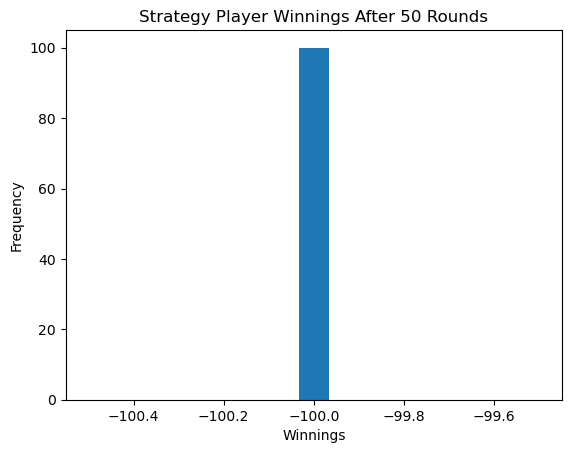

Average winnings per round: -2.0
Standard deviation: 0.0
Probability of net win: 0.0
Probability of net loss: 1.0


In [8]:
import numpy as np
import matplotlib.pyplot as plt

results = []

for g in range(100):   # 100 games
    
    chips = 100
    bet = 10

    for r in range(50):   # 50 rounds
        
        if chips <= 0:
            break
        
        deck = Deck()
        player = StrategyPlayer("Strategy")
        dealer = Dealer()

        player.hand = Hand()
        dealer.hand = Hand()

        for _ in range(2):
            player.hit(deck)
            dealer.hit(deck)

        player.play(deck)
        dealer.play(deck)

        p = player.hand.value()
        d = dealer.hand.value()

        if p <= 21 and (d > 21 or p > d):
            chips += bet
        else:
            chips -= bet

    results.append(chips - 100)   # store winnings


# histogram
plt.hist(results, bins=15)
plt.title("Strategy Player Winnings After 50 Rounds")
plt.xlabel("Winnings")
plt.ylabel("Frequency")
plt.show()


# statistics
avg_per_round = np.mean(results) / 50
std = np.std(results)
prob_win = np.mean(np.array(results) > 0)
prob_loss = np.mean(np.array(results) < 0)

print("Average winnings per round:", avg_per_round)
print("Standard deviation:", std)
print("Probability of net win:", prob_win)
print("Probability of net loss:", prob_loss)

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [9]:
import numpy as np

thresholds = [-4, -2, 0, 2, 4]
results = {}

for t in thresholds:

    winnings = []

    for g in range(100):   # 100 games
        
        chips = 100

        for r in range(50):

            if chips <= 0:
                break

            deck = Deck()
            player = StrategyPlayer("Strategy")
            dealer = Dealer()

            player.threshold = t   # set threshold
            player.hand = Hand()
            dealer.hand = Hand()

            for _ in range(2):
                player.hit(deck)
                dealer.hit(deck)

            player.play(deck)
            dealer.play(deck)

            p = player.hand.value()
            d = dealer.hand.value()

            if p <= 21 and (d > 21 or p > d):
                chips += 10
            else:
                chips -= 10

        winnings.append(chips - 100)

    results[t] = np.mean(winnings)


for t,v in results.items():
    print("Threshold", t, "average winnings:", v)

Threshold -4 average winnings: -98.8
Threshold -2 average winnings: -100.0
Threshold 0 average winnings: -100.0
Threshold 2 average winnings: -100.0
Threshold 4 average winnings: -98.6


10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [11]:
class ConservativePlayer(Player):

    def play(self, deck):
        while self.hand.value() < 15:
            self.hit(deck)

In [12]:
import numpy as np

results = []

for g in range(100):

    chips = 100

    for r in range(50):

        if chips <= 0:
            break

        deck = Deck()
        player = ConservativePlayer("Conservative")
        dealer = Dealer()

        player.hand = Hand()
        dealer.hand = Hand()

        for _ in range(2):
            player.hit(deck)
            dealer.hit(deck)

        player.play(deck)
        dealer.play(deck)

        p = player.hand.value()
        d = dealer.hand.value()

        if p <= 21 and (d > 21 or p > d):
            chips += 10
        else:
            chips -= 10

    results.append(chips - 100)

print("Average winnings:", np.mean(results))

Average winnings: -59.6
